# 第 4 章 雲端回測平台

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/4-1_backtest_platform.ipynb)

**對應影片**：第 4 章 單元 4-1 ~ 4-7【雲端回測平台 I ~ VII】（整章共用這一本）

**和影片的差異**

- 資料改從 Binance 公開資料端點下載（`data-api.binance.vision`，不需金鑰、Colab 可用），`get_all_binance` 的寫法和影片一樣。
- `finlab_crypto.setup()` 只會建立 `history/` 暫存資料夾，不再要求連結 Google Drive。
- vectorbt 改版：`cumulative_returns()`、`final_value()`、`daily_returns()`、`drawdown()` 都是要加括號的函式；影片寫法不同時，以本筆記本為準。
- 互動 K 線圖不需要再設定 `CurrentConfig.NOTEBOOK_TYPE`，Colab、Jupyter、VS Code 都能直接顯示。
- 資料比錄影時多了好幾年，所以最佳參數、績效數字會和影片不同，這是正常的。
- 最後附上「補充：停損、停利、移動停損」，對應單元說明裡的「停損停利範例教學」。

各單元的段落標題都標了單元編號，看到哪個影片就跳到哪一段。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

## 4-1 只要一行！下載加密貨幣歷史數據

`get_all_binance(symbol, kline_size)`：

1. `symbol`：交易對，例如 `'BTCUSDT'`
2. `kline_size`：K 線週期，例如 `'1m'`、`'5m'`、`'15m'`、`'30m'`、`'1h'`、`'2h'`、`'4h'`、`'1d'`

下載過的資料會存在 `history/`，下次只補抓最新的 K 線。

In [3]:
import finlab_crypto

finlab_crypto.setup()
ohlcv = finlab_crypto.crawler.get_all_binance('BTCUSDT', '4h')

BTCUSDT 4h: 19936 candles (2017-08-17 ~ 2026-09-24 08:00 UTC)


In [4]:
# head() 看前 5 筆，tail() 看最後 5 筆；括號裡可以指定筆數，例如 head(10)
ohlcv.tail()

,open,high,low,close,volume,close_time,quote_av,trades,tb_base_av,tb_quote_av,ignore
timestamp,,,,,,,,,,,
2026-09-23 16:00:00+00:00,83996.00,84565.21,83500.01,84518.00,3972.56165,1.790194e+12,3.342210e+08,651509.0,2004.79056,1.686995e+08,0.0
2026-09-23 20:00:00+00:00,84518.00,84670.01,84212.68,84397.60,1400.53046,1.790208e+12,1.182414e+08,276560.0,536.34073,4.528370e+07,0.0
2026-09-24 00:00:00+00:00,84397.60,84494.50,83744.70,83934.01,2101.81016,1.790222e+12,1.769598e+08,427549.0,955.43339,8.046551e+07,0.0
2026-09-24 04:00:00+00:00,83934.01,84612.01,83781.89,84524.02,2151.97484,1.790237e+12,1.812283e+08,399139.0,1087.26563,9.159347e+07,0.0
2026-09-24 08:00:00+00:00,84524.02,84622.01,82874.93,83100.00,3133.38311,1.790251e+12,2.619060e+08,421251.0,1353.58195,1.133479e+08,0.0


## 4-2 如何製作買賣訊號？

- [rolling](https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html)、[mean](https://pandas.pydata.org/docs/reference/api/pandas.core.window.rolling.Rolling.mean.html)：計算移動平均
- [shift](https://pandas.pydata.org/docs/reference/api/pandas.Series.shift.html)：把資料往後移一格，用來比較「上一根 K 線」

黃金交叉（短均線由下往上穿過長均線）買進，死亡交叉賣出。

<Axes: >

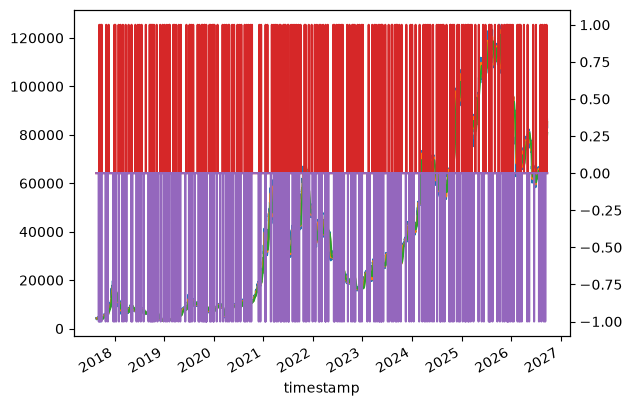

In [5]:
close = ohlcv.close

sma20 = close.rolling(20).mean()
sma60 = close.rolling(60).mean()

entries = (sma20 > sma60) & (sma20.shift() < sma60.shift())
exits = (sma20 < sma60) & (sma20.shift() > sma60.shift())

close.plot()
sma20.plot()
sma60.plot()
entries.astype(int).plot(secondary_y=True)
(-exits.astype(int)).plot(secondary_y=True)

## 4-3 如何快速回測交易訊號？

[vectorbt 文件](https://vectorbt.dev/)：`Portfolio.from_signals` 依照進出場訊號模擬交易。
預設手續費與滑價各 0.1%（`finlab_crypto` 載入時設定）。

<Axes: xlabel='timestamp'>

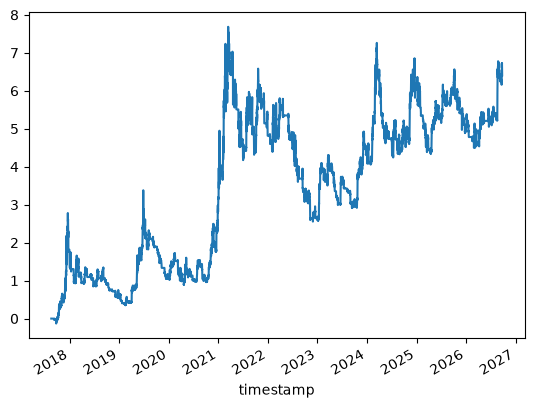

In [6]:
import vectorbt as vbt

portfolio = vbt.Portfolio.from_signals(close, entries, exits, freq='4h')
portfolio.cumulative_returns().plot()

In [7]:
# 每一筆交易的明細
portfolio.positions.records

,id,col,size,entry_idx,entry_price,entry_fees,exit_idx,exit_price,exit_fees,pnl,return,direction,status,parent_id
0,0,0,0.022950,134,4352.99865,0.099900,141,4249.44630,0.097524,-2.573921,-0.025765,0,1,0
1,1,0,0.024755,205,3931.69777,0.097329,226,3776.22000,0.093480,-4.039644,-0.041505,0,1,1
2,2,0,0.023598,241,3953.39945,0.093293,418,5684.30001,0.134139,40.618719,0.435388,0,1,2
3,3,0,0.021978,441,6091.08500,0.133871,514,6500.47302,0.142869,8.720885,0.065144,0,1,3
4,4,0,0.019179,548,7434.42700,0.142583,759,14686.23906,0.281665,138.656870,0.972461,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,189,0,0.009872,19439,62272.21000,0.614741,19573,64492.44300,0.636659,20.666386,0.033618,0,1,189
190,190,0,0.009836,19639,64595.56103,0.635387,19679,63357.68889,0.623211,-13.434790,-0.021144,0,1,190
191,191,0,0.009664,19718,64360.29600,0.621966,19790,78117.81399,0.754916,131.573168,0.211544,0,1,191
192,192,0,0.009266,19815,81306.08486,0.753407,19849,78249.75192,0.725087,-29.799425,-0.039553,0,1,192


In [8]:
# 常用的績效統計一次看
portfolio.stats()

Start                         2017-08-17 04:00:00+00:00
End                           2026-09-24 08:00:00+00:00
Period                               3322 days 16:00:00
Start Value                                       100.0
End Value                                    740.741152
Total Return [%]                             640.741152
Benchmark Return [%]                        1810.349219
Max Gross Exposure [%]                            100.0
Total Fees Paid                              171.174171
Max Drawdown [%]                              64.220278
Max Drawdown Duration                2020 days 08:00:00
Total Trades                                        194
Total Closed Trades                                 193
Total Open Trades                                     1
Open Trade PnL                                16.379726
Win Rate [%]                                  33.160622
Best Trade [%]                                97.246115
Worst Trade [%]                              -16

## 4-4 如何將策略打包重複使用（模組化）？

先把訊號包成函式：

In [9]:
def sma_strategy(ohlcv):
    close = ohlcv.close
    sma20 = close.rolling(20).mean()
    sma60 = close.rolling(60).mean()

    entries = (sma20 > sma60) & (sma20.shift() < sma60.shift())
    exits = (sma20 < sma60) & (sma20.shift() > sma60.shift())
    return entries, exits

In [10]:
sma_strategy(ohlcv)

(timestamp
 2017-08-17 04:00:00+00:00    False
 2017-08-17 08:00:00+00:00    False
 2017-08-17 12:00:00+00:00    False
 2017-08-17 16:00:00+00:00    False
 2017-08-17 20:00:00+00:00    False
                              ...  
 2026-09-23 16:00:00+00:00    False
 2026-09-23 20:00:00+00:00    False
 2026-09-24 00:00:00+00:00    False
 2026-09-24 04:00:00+00:00    False
 2026-09-24 08:00:00+00:00    False
 Name: close, Length: 19936, dtype: bool,
 timestamp
 2017-08-17 04:00:00+00:00    False
 2017-08-17 08:00:00+00:00    False
 2017-08-17 12:00:00+00:00    False
 2017-08-17 16:00:00+00:00    False
 2017-08-17 20:00:00+00:00    False
                              ...  
 2026-09-23 16:00:00+00:00    False
 2026-09-23 20:00:00+00:00    False
 2026-09-24 00:00:00+00:00    False
 2026-09-24 04:00:00+00:00    False
 2026-09-24 08:00:00+00:00    False
 Name: close, Length: 19936, dtype: bool)

### 用 `@Strategy` 裝飾子（decorator）加上回測功能

[什麼是 decorator？](https://book.pythontips.com/en/latest/decorators.html)
decorator 讓函式多了「外掛」：加上 `@Strategy(...)` 之後，`sma_strategy` 就能 `.backtest()`。

- `@Strategy(sma1=20, sma2=60)` 設定參數預設值，函式裡用 `sma_strategy.sma1` 讀取。
- 回傳的第三個值 `figures` 決定圖上要畫什麼：`overlaps` 疊在 K 線上，`figures` 畫在下方。
- `plot=True` 顯示互動 K 線圖（可縮放、拖曳）。

In [11]:
from finlab_crypto import Strategy


@Strategy(sma1=20, sma2=60)
def sma_strategy(ohlcv):
    close = ohlcv.close
    sma20 = close.rolling(sma_strategy.sma1).mean()
    sma60 = close.rolling(sma_strategy.sma2).mean()

    entries = (sma20 > sma60) & (sma20.shift() < sma60.shift())
    exits = (sma20 < sma60) & (sma20.shift() > sma60.shift())

    figures = {
        'overlaps': {
            'sma20': sma20,
            'sma60': sma60,
        }
    }
    return entries, exits, figures


portfolio = sma_strategy.backtest(ohlcv, freq='4h', plot=True)

## 4-5 如何找到策略最佳參數？

`variables` 裡放陣列，就會把所有組合都回測一次，並畫出：

1. **Backtest Results**：前 10 名的累積報酬；前 5、10、20、30 名一起看的最大回檔
2. **Partial Differentiation**：每個參數對績效的平均影響
3. **Combinatorially Symmetric Cross-validation**：過擬合分析（4-6、4-7 說明）
4. 最下方的下拉選單：選兩個參數畫熱力圖

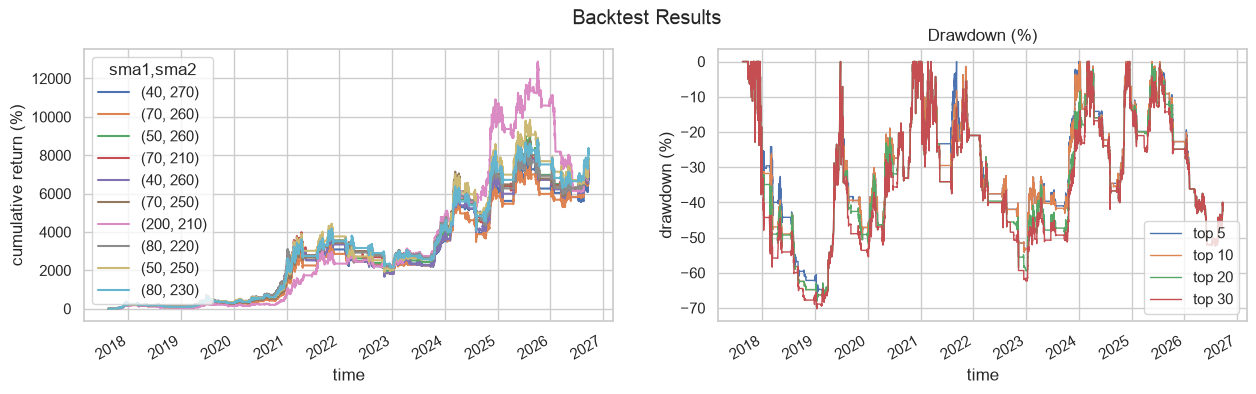

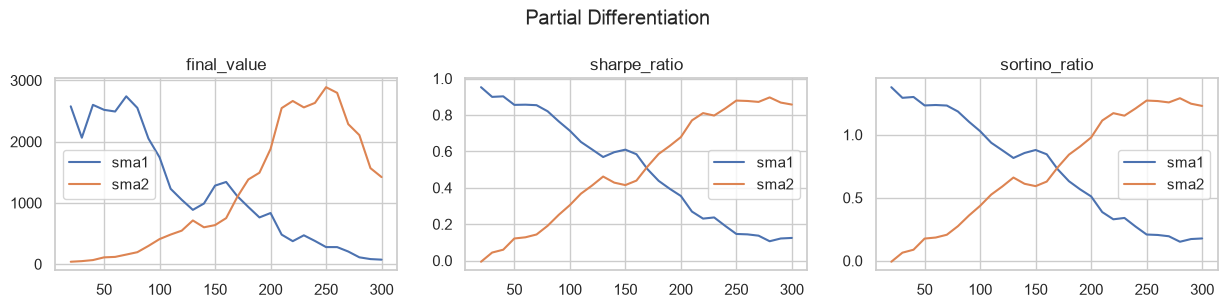

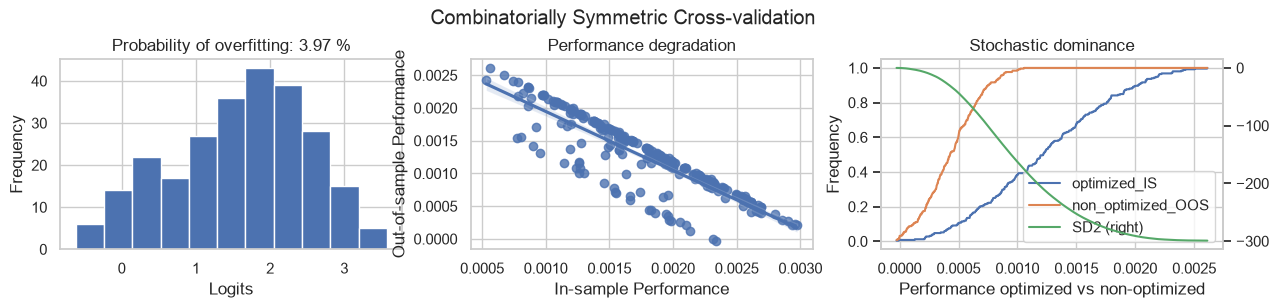

In [12]:
import numpy as np

step = 40 if QUICK_RUN else 10
variables = {'sma1': np.arange(20, 310, step), 'sma2': np.arange(20, 310, step)}
portfolio = sma_strategy.backtest(ohlcv, variables=variables, freq='4h', plot=True)

夏普率前 5 名（沒有任何交易的參數組合，夏普率會是無限大 inf，先換成空值排除）：

In [13]:
sharpe = portfolio.sharpe_ratio().replace([np.inf, -np.inf], np.nan)
sharpe.nlargest(5)

sma1  sma2
80    230     1.265006
      220     1.250030
50    250     1.245385
40    260     1.237975
70    210     1.236546
Name: sharpe_ratio, dtype: float64

看最佳參數的回檔。單元說明裡的 `portfolio.drawdown()[(100, 120)]` 也是同樣的寫法，括號內是 `(sma1, sma2)`。

<Axes: title={'center': 'drawdown, sma1=80, sma2=230'}, xlabel='timestamp'>

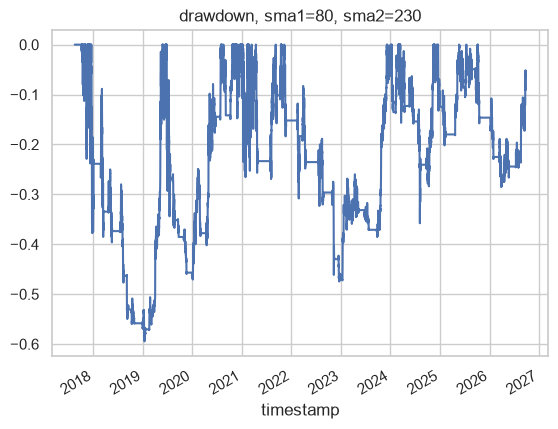

In [14]:
best = sharpe.idxmax()
portfolio.drawdown()[best].plot(title=f'drawdown, sma1={best[0]}, sma2={best[1]}')

## 4-6 如何驗證策略過擬合？原理篇

論文：[The Probability of Backtest Overfitting](https://www.davidhbailey.com/dhbpapers/backtest-prob.pdf)

CSCV（Combinatorially Symmetric Cross-Validation）把歷史報酬切成 10 段，任選 5 段當「樣本內」、其餘 5 段當「樣本外」，
共 252 種切法。每一種切法都看：樣本內最好的參數，到了樣本外排第幾名？
如果常常掉到中位數以下，就代表最佳化找到的只是雜訊 —— 也就是過擬合。

## 4-7 如何驗證策略過擬合？圖表篇

最佳化時已經畫出 CSCV 的三張圖，也可以單獨計算：

1. **Probability of overfitting**：樣本內最佳參數在樣本外表現低於中位數的機率，越低越好
2. **Performance degradation**：樣本內 vs. 樣本外績效，斜率越平代表越多「好運」撐起的績效
3. **Stochastic dominance**：最佳化選出的參數（optimized_IS）vs. 隨便選（non_optimized_OOS）的績效分布；
   `SD2`（second-order stochastic dominance）為負且一路往下，代表最佳化確實有幫助

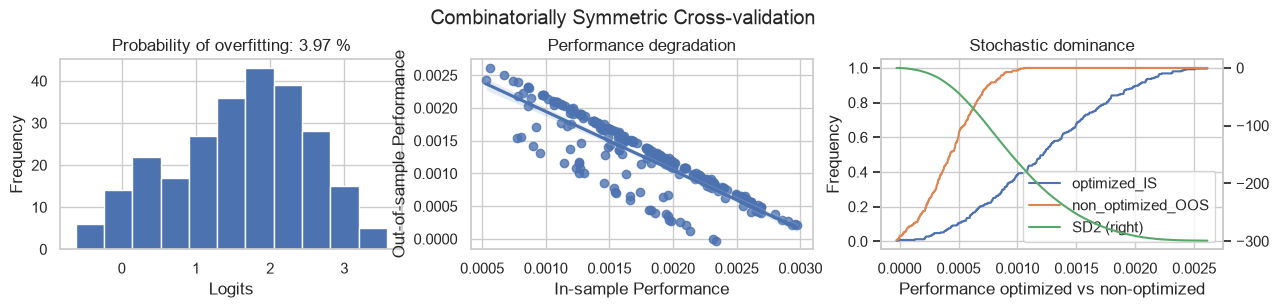

過擬合機率 0.03968253968253968


In [15]:
from finlab_crypto.overfitting import CSCV

cscv = CSCV(n_bins=10, objective=lambda r: r.mean())
cscv.add_daily_returns(portfolio.daily_returns())
result = cscv.estimate_overfitting(plot=True)
print('過擬合機率', result['pbo_test'])

## 補充：停損、停利、移動停損

策略參數裡可以直接加上出場條件：

| 參數 | 意義 | 範例 |
|---|---|---|
| `sl_stop` | 停損：跌破進場價 x% 出場 | `'sl_stop': 0.05` |
| `tp_stop` | 停利：漲超過進場價 x% 出場 | `'tp_stop': 0.1` |
| `ts_stop` | 移動停損：從持有期間最高點回落 x% 出場 | `'ts_stop': 0.05` |

和一般參數一樣可以最佳化，例如 `'sl_stop': np.arange(0.01, 0.2, 0.05)`。
`sl_stop` 與 `ts_stop` 擇一使用。

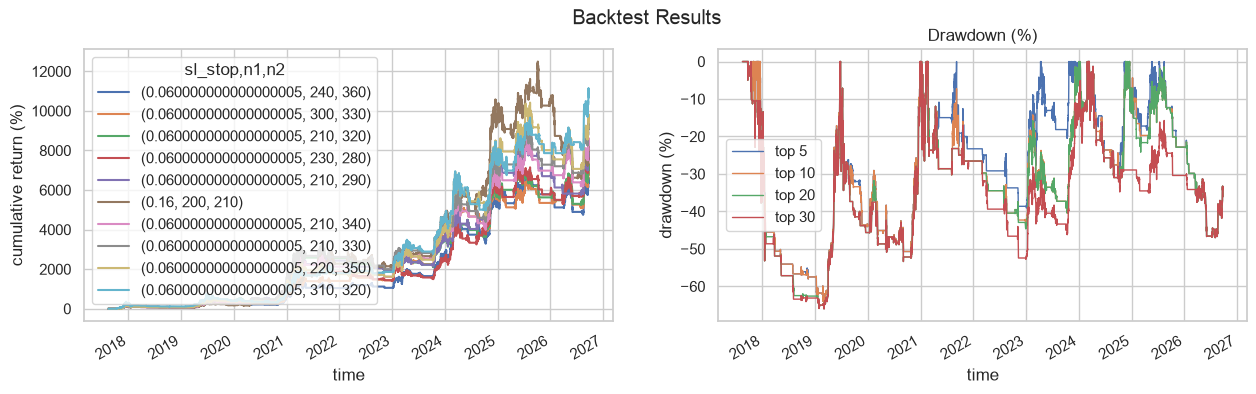

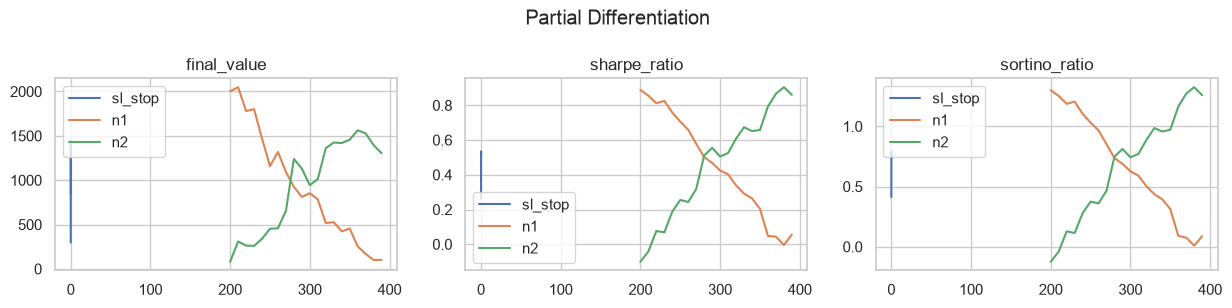

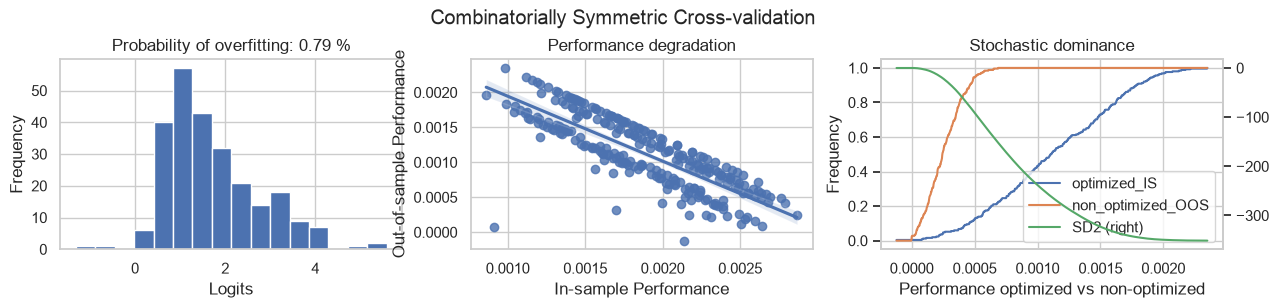

In [16]:
@Strategy(n1=20, n2=60)
def cross_strategy(ohlcv):
    sma1 = ohlcv.close.rolling(cross_strategy.n1).mean()
    sma2 = ohlcv.close.rolling(cross_strategy.n2).mean()
    return (sma1 > sma2) & (sma1.shift() < sma2.shift()), (sma1 < sma2) & (sma1.shift() > sma2.shift())


step = 100 if QUICK_RUN else 10
variables = {
    'n1': np.arange(200, 400, step),
    'n2': np.arange(200, 400, step),
    'sl_stop': np.arange(0.01, 0.2, 0.05),
}
portfolio = cross_strategy.backtest(ohlcv, variables, freq='4h', plot=True)

In [17]:
# 單一組參數加上 10% 移動停損
portfolio = cross_strategy.backtest(ohlcv, {'n1': 20, 'n2': 60, 'ts_stop': 0.1}, freq='4h', plot=True)
portfolio.stats()

Start                          2017-08-17 04:00:00+00:00
End                            2026-09-24 08:00:00+00:00
Period                                3322 days 16:00:00
Start Value                                        100.0
End Value                                     486.313335
Total Return [%]                              386.313335
Benchmark Return [%]                         1810.349219
Max Gross Exposure [%]                             100.0
Total Fees Paid                               116.434406
Max Drawdown [%]                                52.46627
Max Drawdown Duration                 1086 days 16:00:00
Total Trades                                         194
Total Closed Trades                                  193
Total Open Trades                                      1
Open Trade PnL                                 10.753661
Win Rate [%]                                   34.196891
Best Trade [%]                                  61.42629
Worst Trade [%]                